# Analyse Exploratoire des Données (EDA) - Archelec

Ce notebook répond aux exigences d'analyse de données (EDA) du projet. Il est divisé en deux sections :
1. **Analyse générale du corpus** : volumétrie, nettoyage, longueur des textes et intégrité des métadonnées.
2. **Analyse ciblée pour la génération** : validation de la variable conditionnelle `famille_politique` par l'analyse du style (verbosité) et des spécificités lexicales (TF-IDF).

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
from pathlib import Path
import re
from sklearn.feature_extraction.text import TfidfVectorizer

# Configuration visuelle des graphiques
sns.set_theme(style="whitegrid")

## 1. Chargement et Nettoyage des Données

In [13]:
# --- Fichiers texte à charger ---
PATTERNS = [
    "data/1981/legislatives/*PF*.txt",
    "data/1988/legislatives/*PF*.txt",
    "data/1993/legislatives/*PF*.txt",
]

files = []
for p in PATTERNS:
    files.extend(sorted(Path().glob(p)))

dataset = load_dataset("text", data_files=PATTERNS, split="train", sample_by="document")
print(f"Dataset brut chargé : {len(dataset)} documents")

# --- Métadonnées ---
metadata = pd.read_csv("data/archelect_search.csv")
COLS_META = ["id", "titulaire-prenom", "titulaire-nom", "titulaire-profession",
             "titulaire-soutien", "contexte-tour", "date", "departement-nom"]
metadata_dict = metadata[COLS_META].set_index("id").to_dict("index")

def add_metadata(example, idx):
    path = files[idx]
    doc_id = path.stem
    example["id"] = doc_id
    example["annee"] = path.parts[-3]

    meta = metadata_dict.get(doc_id, {})
    example["prenom"]     = meta.get("titulaire-prenom", "non mentionné")
    example["nom"]        = meta.get("titulaire-nom", "non mentionné")
    example["profession"] = meta.get("titulaire-profession", "non mentionné")
    example["soutien"]    = meta.get("titulaire-soutien", "non mentionné")
    example["tour"]       = meta.get("contexte-tour", "non mentionné")
    example["date"]       = meta.get("date", "non mentionné")
    example["departement"]= meta.get("departement-nom", "non mentionné")
    return example

dataset = dataset.map(add_metadata, with_indices=True)
df = dataset.to_pandas()

Resolving data files:   0%|          | 0/12498 [00:00<?, ?it/s]

Dataset brut chargé : 12498 documents


In [14]:
# Nettoyage OCR (Reprise des Regex du notebook principal)
_RE_HYPHENATION = re.compile(r'([A-Za-zÀ-ÿ]+)-\s+([A-Za-zÀ-ÿ]+)')
_RE_ISOLATED_CAP = re.compile(r'\b([A-Z])\s+([A-Z]+\b)')
_RE_WATERMARK  = re.compile(r'Sciences Po / fonds CEVIPOF|[☐☒@¥]')
_RE_VU_CAND    = re.compile(r'vu\s*[,:\-]?\s*(le|la|les)\s+candidat[e]?[s]?\s*[:.]?', re.IGNORECASE)
_RE_DROP_LINE  = re.compile(r'^.*(imp\.?\s|imprimerie|imprimeurs|r\.?c\.?\s|\b\d{5}\b|\b\d{1,2}([\s.\-]?\d{2}){3}\b).*$', re.IGNORECASE | re.MULTILINE)
_RE_MULTILINE  = re.compile(r'\n{3,}')
_RE_MULTSPACE  = re.compile(r' {2,}')
_RE_ENUM       = re.compile(r'[:\n]\s*[•*>.o·]\s*', re.MULTILINE)

def clean_text(text):
    text = str(text)
    text = _RE_HYPHENATION.sub(r'\1\2', text)
    text = _RE_ISOLATED_CAP.sub(r'\1\2', text)
    text = _RE_WATERMARK.sub("", text)          
    text = _RE_VU_CAND.sub("", text)            
    text = _RE_DROP_LINE.sub("", text)          
    text = _RE_MULTILINE.sub('\n\n', text)      
    text = _RE_MULTSPACE.sub(' ', text)         
    text = _RE_ENUM.sub("- ", text)             
    return text.strip()

df['text_clean'] = df['text'].apply(clean_text)
df['word_count'] = df['text_clean'].apply(lambda x: len(x.split()))
print("Nettoyage OCR terminé.")

Nettoyage OCR terminé.


## 2. Analyse Générale du Corpus

On s'intéresse ici à la qualité des données qui seront injectées dans notre LLM : y a-t-il beaucoup de métadonnées manquantes ? Quelle est la longueur moyenne d'un discours politique ?

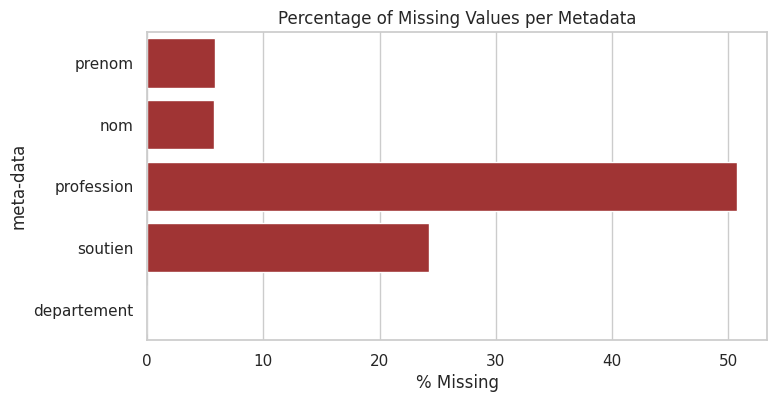

In [15]:
# Analyse des données manquantes (conditionnement)
missing_data = df[['prenom', 'nom', 'profession', 'soutien', 'departement']].apply(lambda x: (x == 'non mentionné').sum() / len(df) * 100)

plt.figure(figsize=(8, 4))

# Utilisation de l'argument color pour une couleur uniforme (ici un rouge standard)
# Cela corrige également le FutureWarning lié à l'utilisation de palette sans hue
sns.barplot(x=missing_data.values, y=missing_data.index, color='firebrick')

# Titres en anglais
plt.title('Percentage of Missing Values per Metadata')
plt.xlabel('% Missing')

# Remplacement de "None" par "meta-data"
plt.ylabel('meta-data')

plt.show()

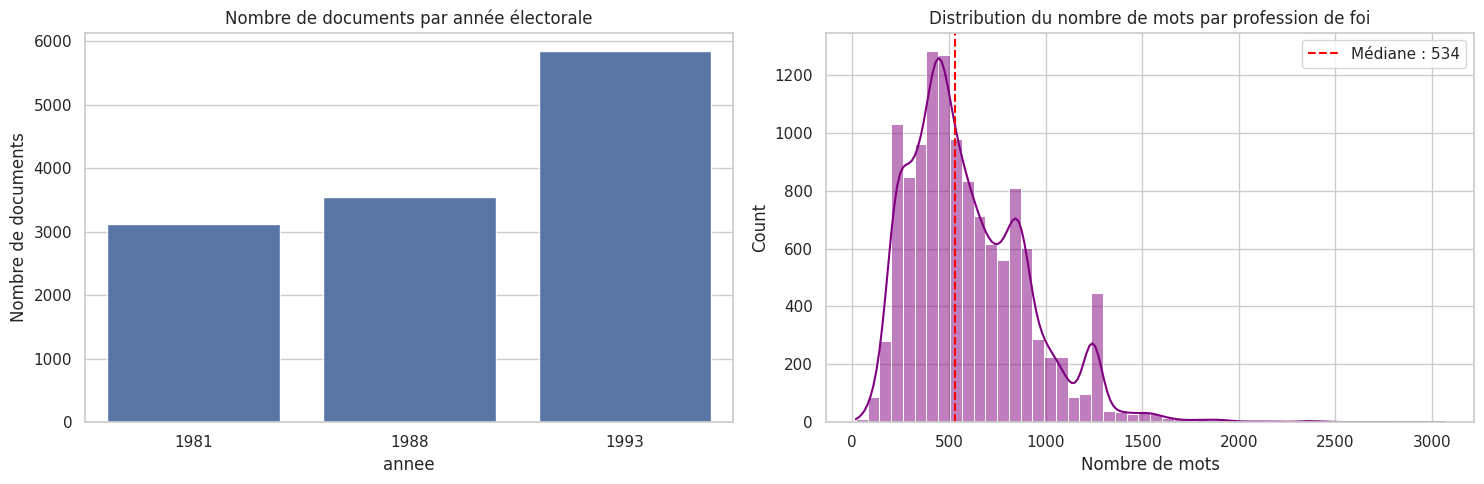

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Répartition par année
sns.countplot(data=df, x='annee', ax=axes[0], color='b')
axes[0].set_title('Nombre de documents par année électorale')
axes[0].set_ylabel('Nombre de documents')

# Distribution de la verbosité (Nombre de mots)
sns.histplot(data=df, x='word_count', bins=50, ax=axes[1], color='purple', kde=True)
axes[1].set_title('Distribution du nombre de mots par profession de foi')
axes[1].set_xlabel('Nombre de mots')
axes[1].axvline(df['word_count'].median(), color='red', linestyle='--', label=f"Médiane : {df['word_count'].median():.0f}")
axes[1].legend()

plt.tight_layout()
plt.show()

## 3. Analyse Ciblée : L'impact de la Famille Politique

Puisque la tâche consiste à générer un texte conditionné sur l'étiquette politique, nous devons valider linguistiquement que l'appartenance à un parti modifie réellement la rhétorique.

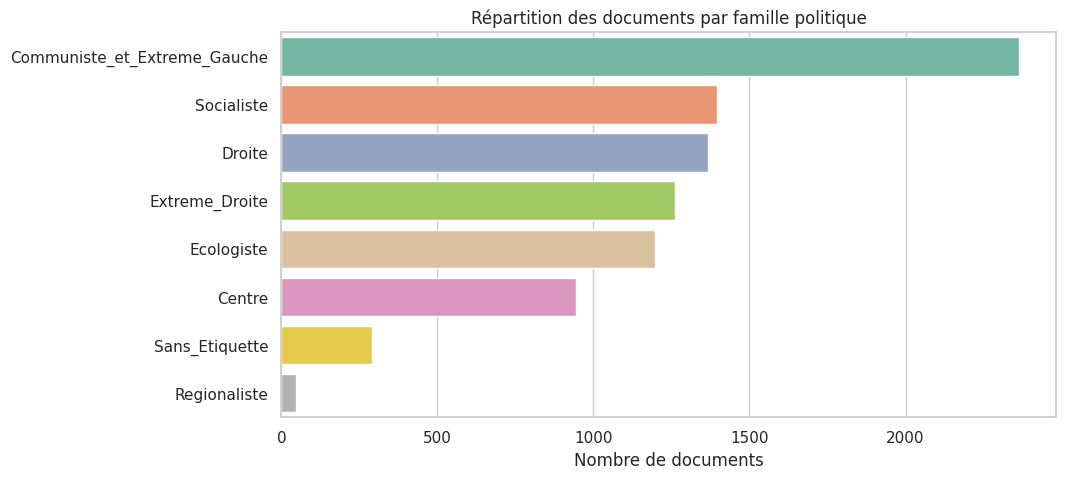

In [17]:
# On utilise ta fonction de normalisation pour agréger les dizaines de petits partis
def normalize_party(soutien):
    if pd.isna(soutien) or soutien == "non mentionné":
        return "A_EXCLURE"
    s = str(soutien).lower().split(';')[0].strip()
    if any(x in s for x in ["front national", "fn", "extrême droite", "trop d'immigrés", "nationaliste", "royaliste", "action française", "forces nouvelles"]):
        return "Extreme_Droite"
    if any(x in s for x in ["communiste", "pcf", "lutte ouvrière", "lcr", "marxiste", "trotskyste", "parti des travailleurs", "rouge et vert", "psu", "parti socialiste unifié", "combat ouvrier", "alternative démocratie socialisme"]):
        return "Communiste_et_Extreme_Gauche"
    if any(x in s for x in ["écolog", "ecolog", "vert", "environnement", "amis de la terre", "nature et animaux", "biosphère"]) and "chasse" not in s:
        return "Ecologiste"
    if any(x in s for x in ["socialiste", "ps", "mrg", "radicaux de gauche", "majorité présidentielle", "gauche progressiste", "convention des institutions républicaines"]):
        return "Socialiste"
    if any(x in s for x in ["rpr", "rassemblement pour la république", "gaulliste", "cni", "indépendants et paysans", "parti républicain", "droite", "républicain indépendant", "mouvement pour la france"]):
        return "Droite"
    if any(x in s for x in ["udf", "union pour la démocratie française", "centre", "cds", "centriste", "démocratie chrétienne", "parti radical", "radicaux-socialistes", "réformateurs"]):
        return "Centre"
    if any(x in s for x in ["chasse", "cpnt", "rurale"]):
        return "Droite"
    if any(x in s for x in ["corse", "corsica", "kanak", "polynési", "breton", "emgann", "occitan", "catalan", "savoie", "abertzale", "guadeloup", "martiniqu", "indépendantiste", "taatiraa", "tahoeraa"]):
        return "Regionaliste"
    if any(x in s for x in ["sans étiquette", "apolitique", "hors des partis", "indépendant", "libre", "aucun parti", "sans appartenance"]):
        return "Sans_Etiquette"
    return "A_EXCLURE"

df['famille_politique'] = df['soutien'].apply(normalize_party)
df_cibled = df[df['famille_politique'] != "A_EXCLURE"].copy()

plt.figure(figsize=(10, 5))
order = df_cibled['famille_politique'].value_counts().index
sns.countplot(data=df_cibled, y='famille_politique', hue='famille_politique', order=order, palette='Set2', legend=False)
plt.title('Répartition des documents par famille politique')
plt.xlabel('Nombre de documents')
plt.ylabel('')
plt.show()

### Répartition temporelle par famille politique
Regardons également comment ces familles politiques se répartissent selon les années d'élections.

<Figure size 1000x600 with 0 Axes>

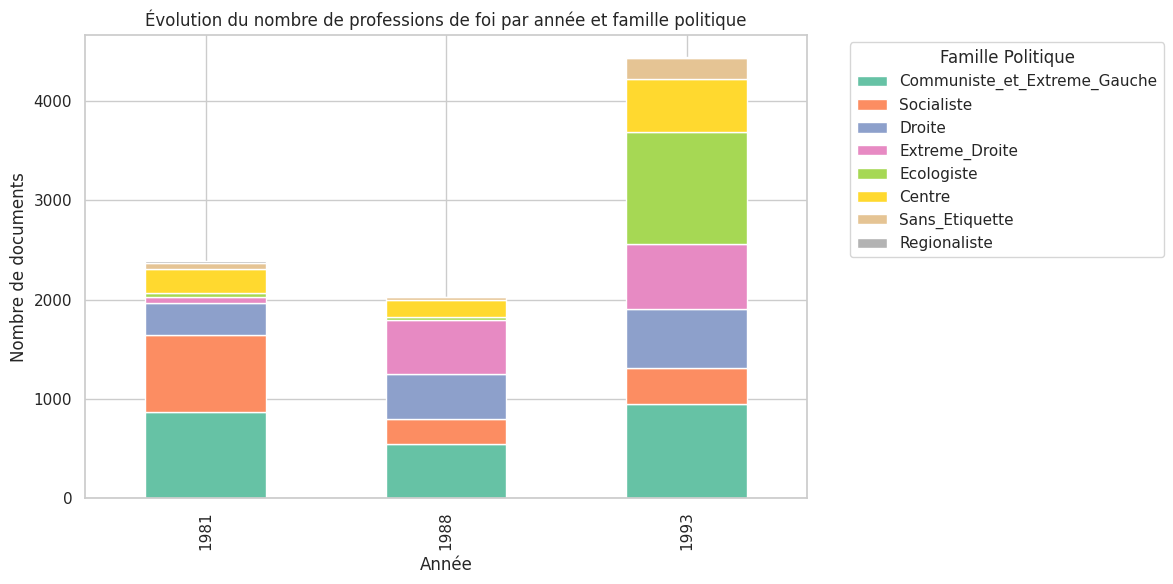

In [18]:
plt.figure(figsize=(10, 6))
counts = df_cibled.groupby(['annee', 'famille_politique']).size().unstack(fill_value=0)
# On garde l'ordre existant pour les couleurs
counts = counts[[p for p in order if p in counts.columns]]
counts.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='Set2', edgecolor='white')
plt.title('Évolution du nombre de professions de foi par année et famille politique')
plt.xlabel('Année')
plt.ylabel('Nombre de documents')
plt.legend(title='Famille Politique', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

### A. Analyse du Style : La verbosité par parti
On cherche à savoir si certaines familles politiques ont tendance à produire des textes structurellement plus longs.

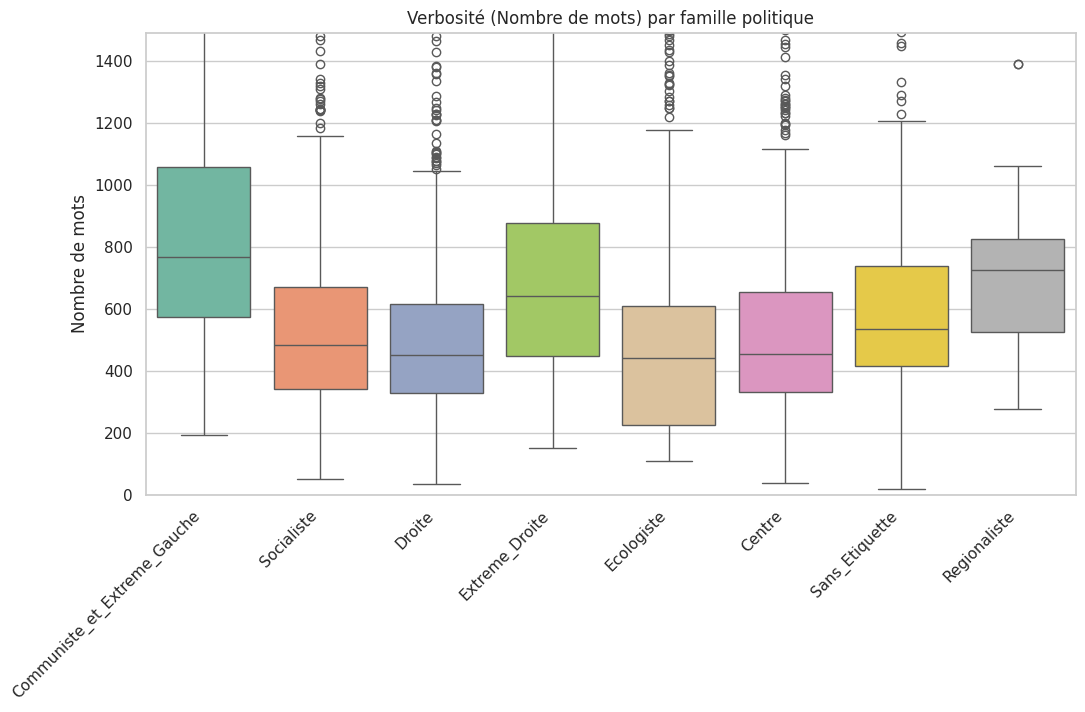

Analyse : Une différence dans les médianes et l'amplitude des textes justifie l'intérêt d'un LLM capable d'adapter le style et la longueur de la réponse générée.


In [19]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_cibled, x='famille_politique', y='word_count', hue = 'famille_politique', order=order, palette='Set2', legend=False)
plt.title('Verbosité (Nombre de mots) par famille politique')
plt.xlabel('')
plt.ylabel('Nombre de mots')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, df_cibled['word_count'].quantile(0.95) * 1.2)
plt.show()

print("Analyse : Une différence dans les médianes et l'amplitude des textes justifie l'intérêt d'un LLM capable d'adapter le style et la longueur de la réponse générée.")

### B. Analyse Lexicale : Champs lexicaux spécifiques (TF-IDF)
En calculant le TF-IDF moyen, on peut extraire la fameuse "Langue de Bois" (The Wooden Language) spécifique à chaque parti. C'est l'argument principal pour entraîner un modèle génératif.

/opt/python/lib/python3.13/site-packages/sklearn/feature_extraction/text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['legislativ', 'luir'] not in stop_words.
  warnings.warn(


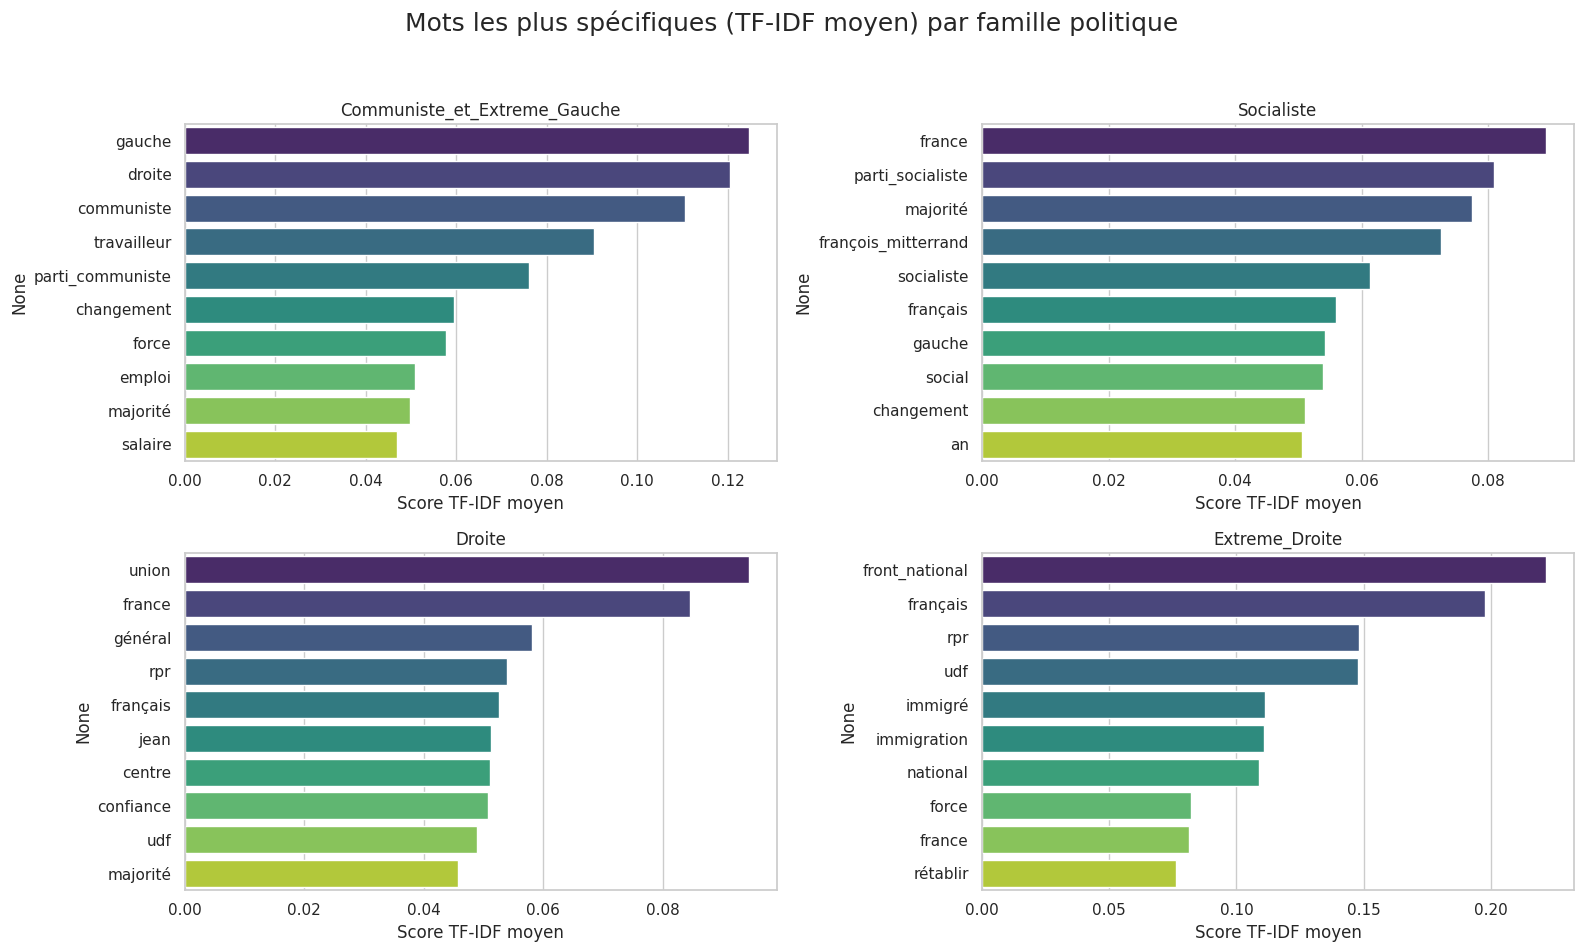

In [20]:
# On se concentre sur 4 grandes familles pour une visualisation claire
familles_cibles = ["Communiste_et_Extreme_Gauche", "Socialiste", "Droite", "Extreme_Droite"]
df_tfidf = df_cibled[df_cibled['famille_politique'].isin(familles_cibles)].copy()

# TF-IDF : max_df=0.8 ignore les "stop words" politiques globaux (ex: France, République, candidat)
# min_df=0.05 assure qu'un mot est quand même assez fréquent pour être un vrai trait de style
import nltk
import re
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
french_stopwords = stopwords.words('french')

# 1. Ajout des mots inintéressants et génériques
custom_stopwords = [
    '000', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '1978', '1981', '1986', '1988', '1992', '1993', '1er', '20', '21', '24', '25', '28', '2e', '35', '3e', '40', '400', '500', '60', '92', 'cinq', 'deux', 'deuxième', 'dix', 'neuf', 'trois', 'vingt',
    'abord', 'afin', 'ailleurs', 'ainsi', 'aller', 'allez', 'alors', 'après', 'assez', 'aucun', 'aucune', 'aujourd', 'aussi', 'autant', 'autour', 'autre', 'autrement', 'autres', 'avant', 'avoir', 'beaucoup', 'bien', 'bon', 'bonne', 'car', 'cela', 'celle', 'celles', 'celui', 'certains', 'cet', 'cette', 'ceux', 'chacun', 'chaque', 'chez', 'comme', 'comment', 'contre', 'côté', 'côtés', 'davantage', 'demain', 'depuis', 'dernier', 'devant', 'dire', 'dit', 'doit', 'doivent', 'donc', 'dont', 'dès', 'déjà', 'effet', 'elles', 'encore', 'enfin', 'ensemble', 'entre', 'etc', 'face', 'faire', 'fait', 'faites', 'faudra', 'faut', 'fera', 'ferons', 'fois', 'font', 'hier', 'hui', 'ici', 'jamais', 'jusqu', 'laquelle', 'lequel', 'leurs', 'lors', 'lorsqu', 'là', 'maintenant', 'malheureusement', 'mettant', 'mettre', 'mieux', 'mis', 'mise', 'moins', 'ni', 'nom', 'nombre', 'nombreuses', 'nombreux', 'non', 'nouveau', 'nouveaux', 'nouvelle', 'nouvelles', 'or', 'oui', 'où', 'parce', 'parmi', 'partout', 'pendant', 'pense', 'peut', 'peuvent', 'plus', 'plusieurs', 'pourquoi', 'pourraient', 'pourtant', 'pouvez', 'prendre', 'presque', 'pris', 'puis', 'puisse', 'quand', 'quel', 'quelle', 'quelques', 'quoi', 'rien', 'sais', 'sans', 'savez', 'seul', 'seule', 'seulement', 'seuls', 'si', 'simplement', 'sous', 'suffit', 'tant', 'tel', 'toujours', 'tous', 'tout', 'toute', 'toutes', 'très', 'trop', 'uns', 'va', 'vers', 'veulent', 'veut', 'veux', 'vient', 'voilà', 'voir', 'vont', 'voulez', 'voulons', 'voulu', 'vrai', 'vraiment', 'vu', 'ça', 'être',
    'candidat', 'candidate', 'candidats', 'candidature', 'canton', 'citoyens', 'compatriotes', 'conseil', 'conseiller', 'dimanche', 'département', 'départemental', 'député', 'députés', 'electeurs', 'elections', 'electrices', 'gouvernement', 'gouvernements', 'legislatives', 'législatives', 'madame', 'mademoiselle', 'maire', 'mandat', 'ministre', 'ministres', 'monsieur', 'parlement', 'parlementaire', 'politique', 'politiques', 'premier', 'première', 'président', 'présidentielle', 'présidentielles', 'republique', 'république', 'scrutin', 'suffrage', 'suffrages', 'suppléant', 'suppléante', 'tour', 'votant', 'vote', 'voter', 'votes', 'votez', 'voté', 'électeurs', 'élection', 'élections', 'électorale', 'électrices', 'élire', 'élu', 'élus', 'état', 'avril', 'juin', 'mai', 'mars'
]
all_stopwords = french_stopwords + custom_stopwords

# 2. Fusion des mots composés pertinents
replacements = {
    r"\bfront national\b": "front_national",
    r"\bfrançois mitterrand\b": "françois_mitterrand",
    r"\bjacques chirac\b": "jacques_chirac",
    r"\b(général|charles) de gaulle\b": "général_de_gaulle",
    r"\bjean[\s\-]marie le pen\b": "jean_marie_le_pen",
    r"\bmajorité présidentielle\b": "majorité_présidentielle",
    r"\bvaléry giscard d[' ]estaing\b": "giscard_destaing",
    r"\bgiscard d[' ]estaing\b": "giscard_destaing",
    r"\bpierre mauroy\b" : "pierre_mauroy",
    r"\bjean lecanuet\b" : "jean_lecanuet",
    r"\blionel jospin\b" : "lionel_jospin",
    r"\bandré lajoinie\b" : "andre_lajoinie",
    r"\bmichel rocard\b" : "michel_rocard",
    r"\bsimone veil\b" : "simone_veil",
    r"\bcharles_pasqua\b" : "charles_pasqua",
    r"\bparti communiste\b": "parti_communiste",
    r"\bparti socialiste\b": "parti_socialiste",
    r"\bextrême droite\b": "extrême_droite",
    r"\bextrême gauche\b": "extrême_gauche",
    r"\blutte ouvrière\b": "lutte_ouvrière",
    r"\bgeorges marchais\b": "georges_marchais",
    r"\braymond barre\b": "raymond_barre",
    r"\bédouard balladur\b": "édouard_balladur",
    r"\bsécurité sociale\b": "sécurité_sociale",
    r"\bpouvoir d[' ]achat\b": "pouvoir_d_achat",
    r"\bpremier ministre\b": "premier_ministre",
    r"\bassemblée nationale\b": "assemblée_nationale",
    r"\bniveau de vie\b" : "niveau_de_vie"
}

for pattern, repl in replacements.items():
    df_tfidf['text_clean'] = df_tfidf['text_clean'].str.replace(pattern, repl, flags=re.IGNORECASE, regex=True)

# 3. Lemmatisation (SpaCy) pour obtenir des mots ayant un sens (au lieu du Stemming)
import spacy
try:
    nlp = spacy.load('fr_core_news_sm', disable=['parser', 'ner'])
except OSError:
    import spacy.cli
    spacy.cli.download('fr_core_news_sm')
    nlp = spacy.load('fr_core_news_sm', disable=['parser', 'ner'])

# Cache pour accélérer considérablement la lemmatisation par mot
lemma_cache = {}

def lemma_tokenizer(text):
    # Ajout du '_' dans la regex pour bien capturer les mots composés (ex: front_national)
    tokens = re.findall(r"(?u)\b[a-zà-ÿ_]{3,}\b", text.lower())
    lemmas = []
    for t in tokens:
        if '_' in t:
            lemmas.append(t)
        else:
            if t not in lemma_cache:
                lemma_cache[t] = nlp(t)[0].lemma_
            lemmas.append(lemma_cache[t])
    return lemmas

# On lemmatise aussi les stopwords pour que le filtre continue de fonctionner
lemmatized_stopwords = [nlp(w.lower())[0].lemma_ for w in all_stopwords if len(nlp(w.lower())) > 0]

vectorizer = TfidfVectorizer(max_df=0.8, min_df=0.05, stop_words=lemmatized_stopwords, max_features=1000, tokenizer=lemma_tokenizer, token_pattern=None)
tfidf_matrix = vectorizer.fit_transform(df_tfidf['text_clean'])
feature_names = vectorizer.get_feature_names_out()

# Calcul du score TF-IDF moyen par parti
df_tfidf_scores = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
df_tfidf_scores['famille_politique'] = df_tfidf['famille_politique'].values
mean_tfidf_by_party = df_tfidf_scores.groupby('famille_politique').mean()

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Mots les plus spécifiques (TF-IDF moyen) par famille politique', fontsize=18)

for ax, famille in zip(axes.flatten(), familles_cibles):
    top_words = mean_tfidf_by_party.loc[famille].sort_values(ascending=False).head(10)
    sns.barplot(x=top_words.values, y=top_words.index, hue=top_words.index, ax=ax, palette='viridis', legend=False)
    ax.set_title(famille)
    ax.set_xlabel('Score TF-IDF moyen')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

**Richesse lexicale (Type-Token Ratio - TTR)** : Le TTR mesure la diversité du vocabulaire utilisé. Plus le score est proche de 1, plus le vocabulaire est varié (moins de répétitions).

/tmp/ipykernel_94014/1324875501.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_cibled, x='famille_politique', y='ttr', order=order, ax=axes[0], palette='Set2')
/tmp/ipykernel_94014/1324875501.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')


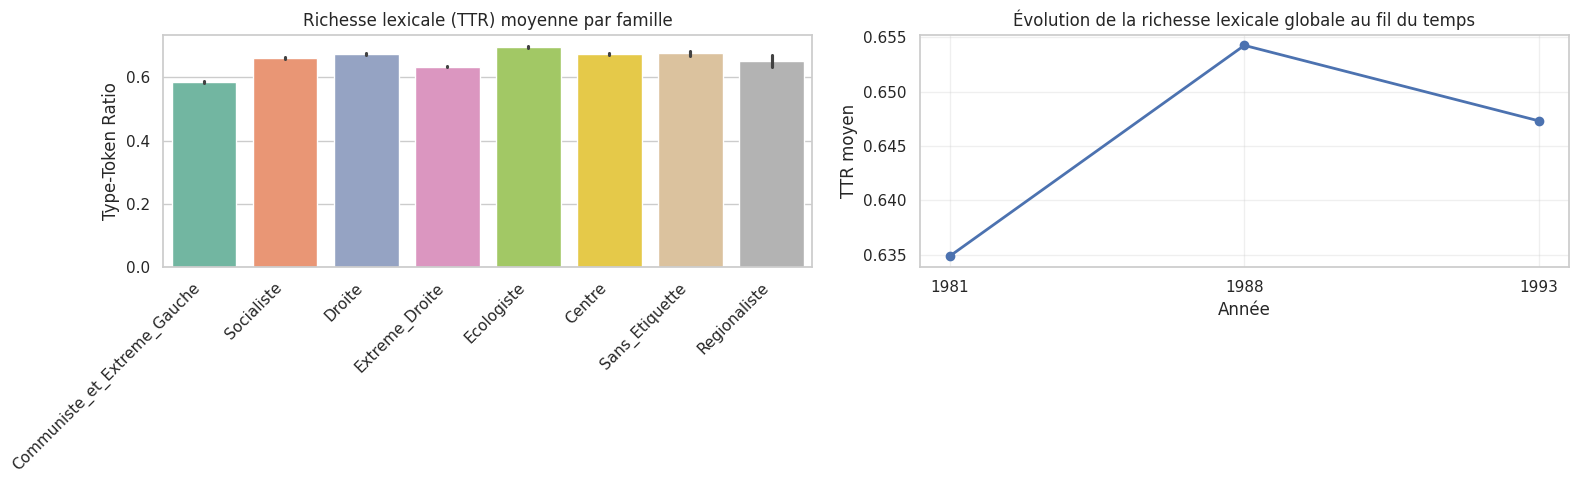

In [21]:
def compute_ttr(text):
    tokens = [t for t in re.findall(r"[a-zà-ÿ]+", str(text).lower()) if len(t) >= 3]
    return len(set(tokens)) / len(tokens) if tokens else 0.0

df_cibled['ttr'] = df_cibled['text_clean'].apply(compute_ttr)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=df_cibled, x='famille_politique', y='ttr', order=order, ax=axes[0], palette='Set2')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].set_title('Richesse lexicale (TTR) moyenne par famille')
axes[0].set_ylabel('Type-Token Ratio')
axes[0].set_xlabel('')

ttr_by_year = df_cibled.groupby('annee')['ttr'].mean()
axes[1].plot(ttr_by_year.index, ttr_by_year.values, marker='o', linewidth=2, color='#4C72B0')
axes[1].set_title('Évolution de la richesse lexicale globale au fil du temps')
axes[1].set_xlabel('Année')
axes[1].set_ylabel('TTR moyen')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
  

### C. Analyse Lexicale par Classe Grammaticale
Séparation des mots TF-IDF en Noms, Noms Propres, Verbes et Adjectifs via SpaCy pour comprendre la structure rhétorique de chaque famille politique.

✔ Download and installation successful
You can now load the package via spacy.load('fr_core_news_sm')
Mots catégorisés : Noms (428), Noms Propres (30), Verbes (237), Adjectifs (142)


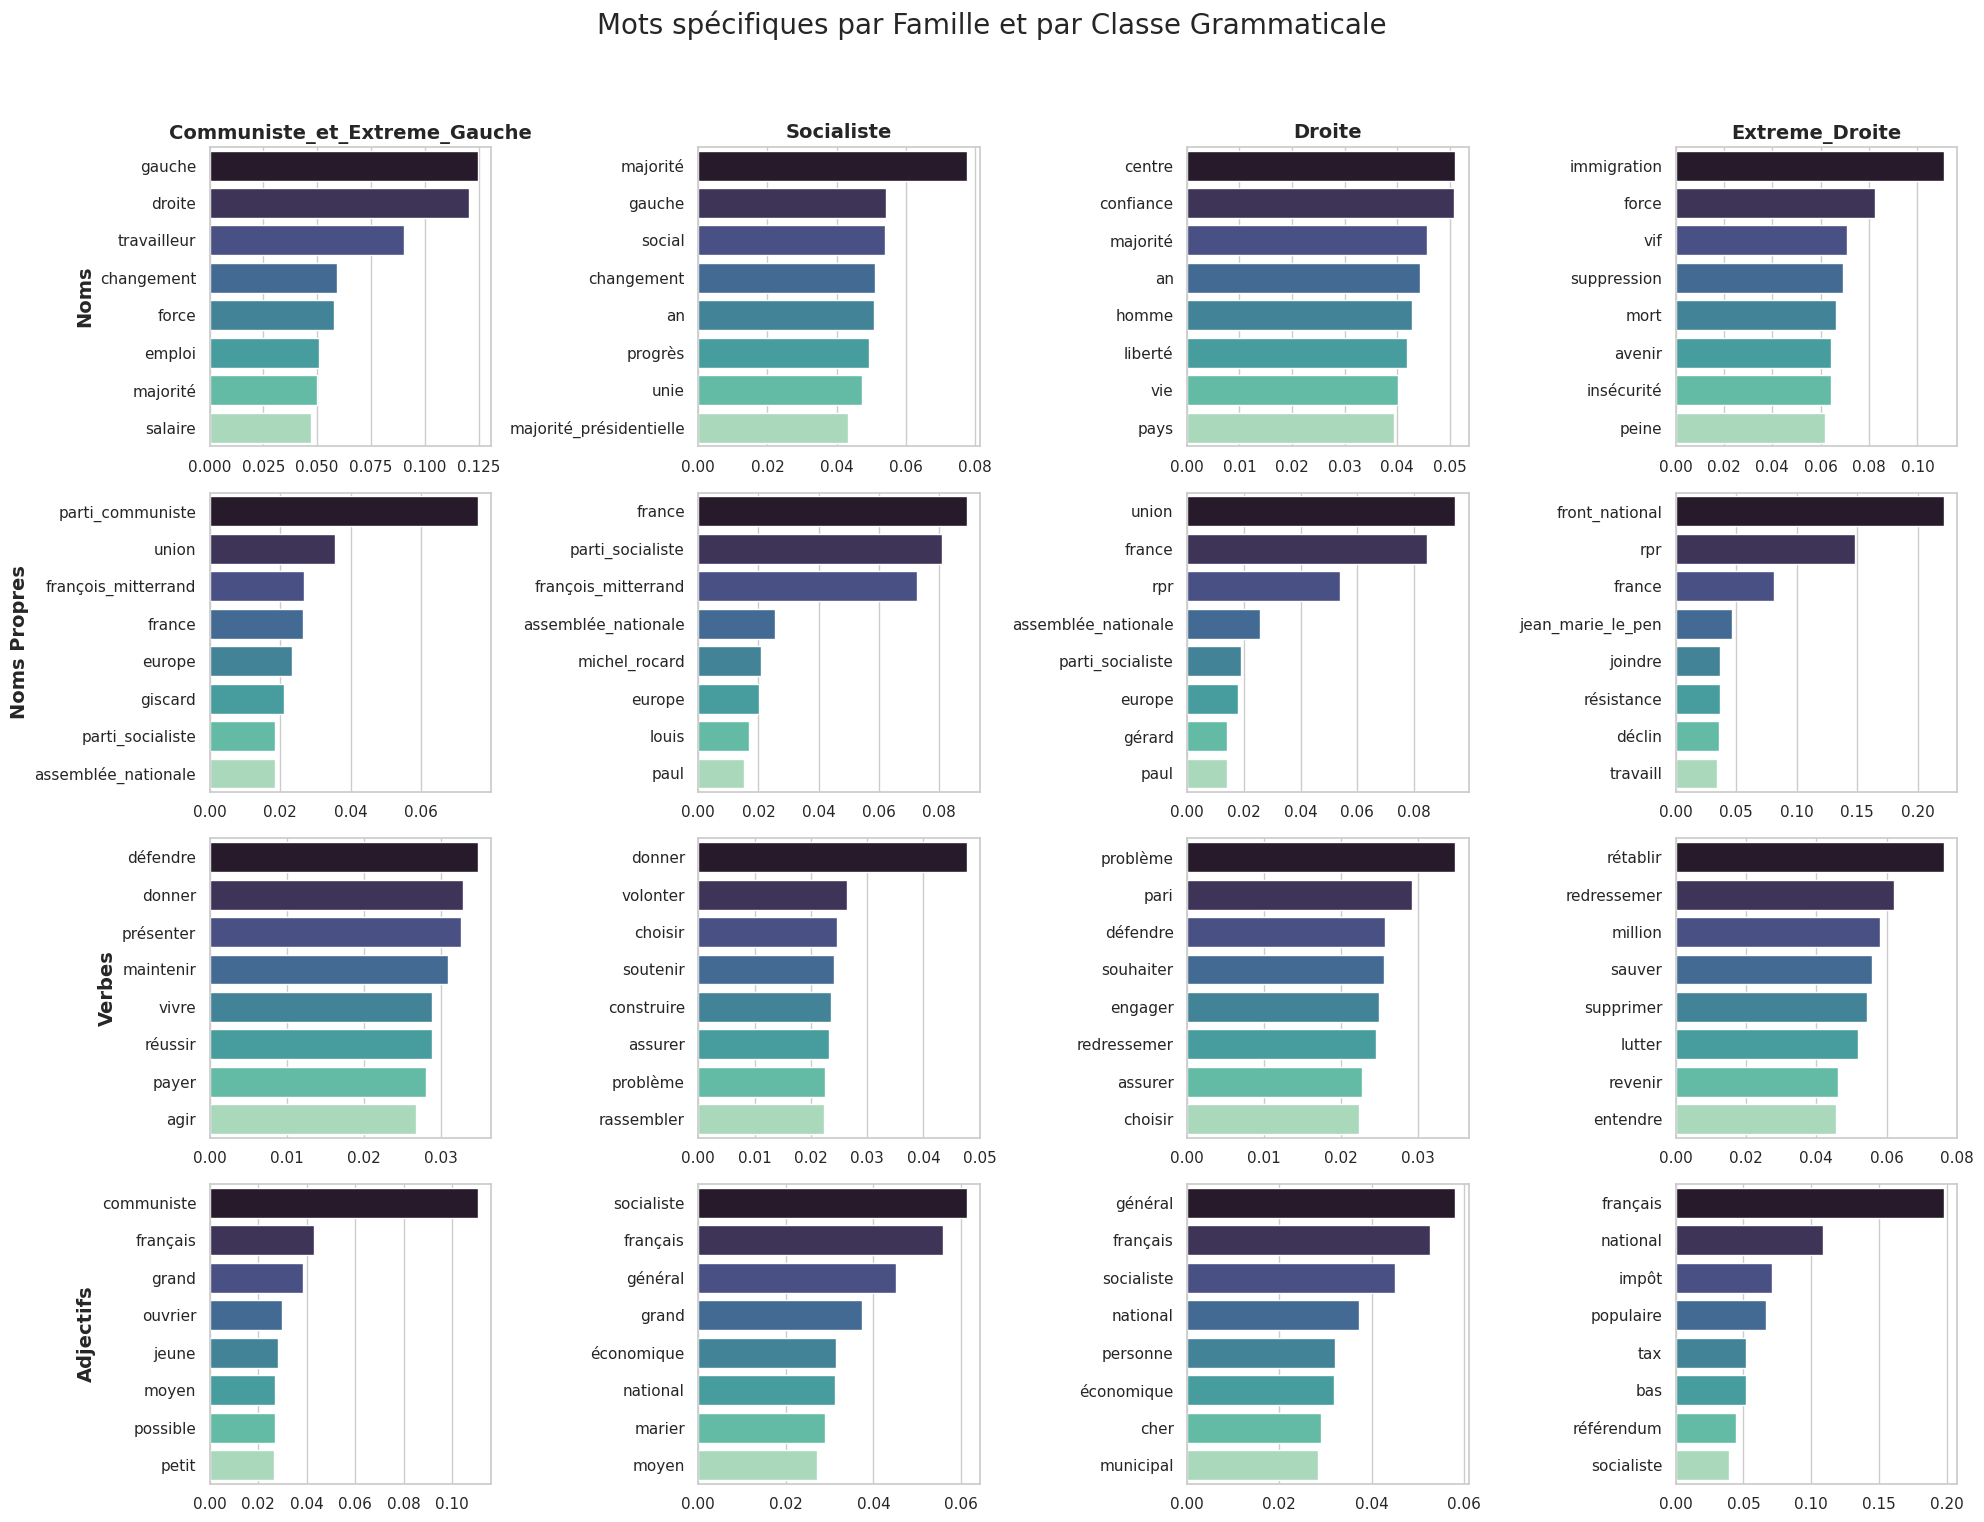

In [22]:
!python -m spacy download fr_core_news_sm -q
import spacy
import numpy as np
nlp = spacy.load('fr_core_news_sm')

# Catégorisation du vocabulaire retenu
vocab_pos = {'NOUN': [], 'PROPN': [], 'VERB': [], 'ADJ': []}

# Prénoms courants à exclure des Noms Propres pour une analyse plus pertinente
prenoms_a_exclure = {'jean', 'jacques', 'michel', 'françois', 'pierre', 'alain', 'philippe', 'charles', 'andré'}

for word in feature_names:
    # Remettre les espaces pour que Spacy taggue correctement les mots composés
    doc = nlp(word.replace('_', ' '))
    
    # Si le mot a été fusionné plus haut, on le force en PROPN si on détecte une entité
    if '_' in word and any(k in word for k in ['national', 'mitterrand', 'chirac', 'gaulle', 'pen', 'socialiste', 'communiste', 'marchais', 'barre', 'balladur']):
        vocab_pos['PROPN'].append(word)
        continue
        
    # Sinon on prend le tag principal du premier token
    pos = doc[0].pos_
    if pos in vocab_pos:
        # On exclut les prénoms courants de la catégorie PROPN
        if pos == 'PROPN' and word in prenoms_a_exclure:
            continue
        vocab_pos[pos].append(word)

print(f"Mots catégorisés : Noms ({len(vocab_pos['NOUN'])}), Noms Propres ({len(vocab_pos['PROPN'])}), Verbes ({len(vocab_pos['VERB'])}), Adjectifs ({len(vocab_pos['ADJ'])})")

# Affichage des tops par parti et par type
fig, axes = plt.subplots(4, len(familles_cibles), figsize=(20, 16))
fig.suptitle('Mots spécifiques par Famille et par Classe Grammaticale', fontsize=20)

pos_titles = {'NOUN': 'Noms', 'PROPN': 'Noms Propres', 'VERB': 'Verbes', 'ADJ': 'Adjectifs'}

for i, (pos_tag, word_list) in enumerate(vocab_pos.items()):
    # Filtrer le DataFrame TF-IDF sur ces mots uniquement
    valid_words = [w for w in word_list if w in mean_tfidf_by_party.columns]
    if not valid_words:
        continue
        
    mean_tfidf_pos = mean_tfidf_by_party[valid_words]
    
    for j, famille in enumerate(familles_cibles):
        ax = axes[i, j]
        top_words = mean_tfidf_pos.loc[famille].sort_values(ascending=False).head(8)
        sns.barplot(x=top_words.values, y=top_words.index, hue=top_words.index, ax=ax, palette='mako', legend=False)
        
        if i == 0:
            ax.set_title(famille, fontsize=14, fontweight='bold')
        if j == 0:
            ax.set_ylabel(pos_titles[pos_tag], fontsize=14, fontweight='bold')
        else:
            ax.set_ylabel('')
        ax.set_xlabel('')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


### D. Visualisation de l'Espace Sémantique (UMAP)
En projetant la matrice TF-IDF en 2 dimensions via UMAP (après une réduction PCA pour éliminer le bruit), nous pouvons observer si les professions de foi se regroupent naturellement par famille politique. UMAP est beaucoup plus rapide que t-SNE.

In [ ]:
!pip install umap-learn -q
import umap
from sklearn.decomposition import TruncatedSVD
import numpy as np

print("Échantillonnage et réduction : TruncatedSVD (50 comp) -> UMAP (2D) ...")

# 1. Échantillonnage pour aller plus vite (max 2500 docs)
max_samples = 2500
n_docs = tfidf_matrix.shape[0]
if n_docs > max_samples:
    np.random.seed(42)
    sample_indices = np.random.choice(n_docs, max_samples, replace=False)
    tfidf_sampled = tfidf_matrix[sample_indices]
    labels_sampled = df_tfidf['famille_politique'].values[sample_indices]
else:
    tfidf_sampled = tfidf_matrix
    labels_sampled = df_tfidf['famille_politique'].values

# 2. Réduction avec TruncatedSVD (sur matrice creuse, beaucoup plus rapide)
svd = TruncatedSVD(n_components=50, random_state=42)
X_svd = svd.fit_transform(tfidf_sampled)
print('SVD done.')
# 3. UMAP
reducer = umap.UMAP(n_components=2, random_state=42)
X_2d = reducer.fit_transform(X_svd)
print('UMAP done.')
# 4. Visualisation
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_2d[:, 0], y=X_2d[:, 1], 
    hue=labels_sampled, 
    palette='Set2', s=40, alpha=0.7, edgecolor=None
)
plt.title(f"Projection UMAP des professions de foi (Échantillon de {len(labels_sampled)} docs)", fontsize=15)
plt.legend(title="Famille politique", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks([])
plt.yticks([])
plt.tight_layout()
plt.show()


**Conclusion de l'analyse exploratoire :**
1. Les données contextuelles sont très complètes (peu de valeurs manquantes).
2. Il y a une disparité claire dans le vocabulaire utilisé. Générer un texte "neutre" ne reflèterait pas la réalité politique.
3. Ces résultats justifient le fine-tuning d'un LLM sur la variable `famille_politique` pour conditionner la génération sémantique et stylistique du texte.